!pip install langgraph langchain langchain-openai openai \
            google-api-python-client google-auth-httplib2 \
            websockets httpx python-dotenv

!pip install langgraph langchain langchain-openai openai \
            #azure-communication-callautomation \
            google-api-python-client google-auth-httplib2 \
            websockets httpx python-dotenv

! pip install google-auth-oauthlib

In [1]:
import sys
print(sys.executable)

C:\anaconda3\envs\genaiproject\python.exe


In [2]:
#!pip freeze > requirements.txt

In [3]:
import os 
from dotenv import load_dotenv
# 🔐 Load API keys
load_dotenv(dotenv_path=".env") 
openai_api_key = os.getenv("OPENAI_API_KEY") 
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [4]:
# Importing langchain/langgraph libraries
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI

In [5]:
# LLM initialisation
llm_openai=ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

In [6]:
llm_openai.invoke("who is the miss universe 2025?")

AIMessage(content="As of now, the Miss Universe 2025 pageant has not yet taken place, so the titleholder for Miss Universe 2025 has not been announced. If you're looking for the most current information, I recommend checking the official Miss Universe website or their social media channels closer to or after the event date.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 16, 'total_tokens': 79, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b80731a437', 'id': 'chatcmpl-DWQFFM6zZ7IdJcz8vfkyWyJvafxZM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da6ca-0ba0-7951-9ecd-3fc811c8944f-0', tool_calls=[], invalid_tool_calls=[], usage_meta

In [7]:
from graph import node_collect_input,node_rag_lookup,node_draft_invite,node_human_approval,node_send_invite,build_graph

In [8]:
from graph import bridge_graph

In [9]:
from state import IncidentState
from sheets import (
    fetch_teams,
    fetch_current_cim,
    fetch_fixed_members,
    get_google_credentials,
)
from calendar_tool import send_calendar_invite, get_calendar_credentials

load_dotenv()

# ---------------------------------------------------------------------------
# Shared resources (initialised once)
# ---------------------------------------------------------------------------
from openai import OpenAI
openai_api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=openai_api_key)# needs to be passed as keyword argument or can be left empty as we fetcg from env variable

# ---------------------------------------------------------------------------
# Shared resources (initialised once)
# ---------------------------------------------------------------------------

llm         = ChatOpenAI(model="gpt-4o-mini", temperature=0)
credentials_sheets = get_google_credentials()
credentials_calendar= get_calendar_credentials()

In [10]:
IncidentState = {"ticket_id": "INC-143",
         "priority": "P2",
         "subject": "wIFI DOWN",
         "context": "connected with affected user the entire plant is down as they are not able to connect to wifi or LAN's in any part of the plant",
         "recipient_emails": "", # Optional list[str] ,    # tech DL emails matched from Sheets
         'cim':        ""  ,   #  Optional dict   ,       # {"name": "Ravi", "phone": "+91XXX"}
         'fixed':      "" ,    #  Optional dict  ,        # fixed emails in the invite

        # --- Draft node output ---
         'draft_invite':   ""  , # Optional[dict],

    # --- Human approval output ---
         'approved_invite':  "" ,#Optional[dict],

    # --- Calendar node output ---
         'meet_link':   ""   ,   #Optional[str]
         }

In [11]:
# Just invoke once — it pauses at input() naturally
config = {"configurable": {"thread_id": "my-incident-123"}}
result = bridge_graph.invoke(IncidentState, config=config)
result


✅ Input received — INC-143 | P2 | wIFI DOWN

🔍 RAG node: fetching teams from Google Sheets...
[['Infra-Network', 'dramal16@gmail.com', "Wifi down , network not connecting, site can't be reached error."], ['Infra-DC&Cloud', 'dramal16@gmail.com', 'application server is slow, hung or rebooted is required.']]
[['Stakeholder', 'mary.amalraj66@gmail.com', 'required'], ['MIM1', 'buelinabisamatrish@gmail.com', 'optional'], ['MIM2', '        Vjr708@gmail.com', 'optional']]
   Matched teams   : ['Infra-Network']
   Required emails : ['mary.amalraj66@gmail.com', 'dramal16@gmail.com', 'muthurajaa01@gmail.com']
   On-call CIM     : Muthu raja

📝 Draft node: generating invite with LLM...

   Draft title : [P2] Bridge Call — INC-143 : wIFI DOWN
   Required    : ['mary.amalraj66@gmail.com', 'dramal16@gmail.com', 'muthurajaa01@gmail.com']
   Optional    : ['buelinabisamatrish@gmail.com', 'Vjr708@gmail.com']

🔔 HUMAN APPROVAL REQUIRED
Title       : [P2] Bridge Call — INC-143 : wIFI DOWN
Start       : 2


Action — [A]pprove / [E]dit :  a



✅ Invite approved.

📅 Calendar node: sending invite...

✅ Calendar invite sent!
   Meet link: https://meet.google.com/ort-xfpm-asa


{'ticket_id': 'INC-143',
 'priority': 'P2',
 'subject': 'wIFI DOWN',
 'context': "connected with affected user the entire plant is down as they are not able to connect to wifi or LAN's in any part of the plant",
 'recipient_emails': ['mary.amalraj66@gmail.com',
  'dramal16@gmail.com',
  'muthurajaa01@gmail.com'],
 'cim': {'name': 'Muthu raja',
  'role': 'primary',
  'email': 'muthurajaa01@gmail.com',
  'phone': '9884554078'},
 'fixed': {'stakeholder_dl': 'mary.amalraj66@gmail.com',
  'optional': ['buelinabisamatrish@gmail.com', 'Vjr708@gmail.com']},
 'draft_invite': {'title': '[P2] Bridge Call — INC-143 : wIFI DOWN',
  'description': 'Scheduling bridge call for troubleshooting',
  'start_time': '2026-04-19T17:45:04.786287+00:00',
  'end_time': '2026-04-19T18:45:04.786287+00:00',
  'required_attendees': ['mary.amalraj66@gmail.com',
   'dramal16@gmail.com',
   'muthurajaa01@gmail.com'],
  'optional_attendees': ['buelinabisamatrish@gmail.com', 'Vjr708@gmail.com'],
  'stakeholder_dl': 'mar

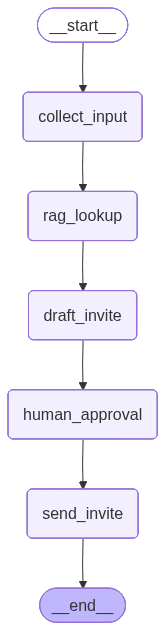

In [12]:
# Visualize the graph
from IPython.display import Image
Image(bridge_graph.get_graph().draw_mermaid_png())